In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import learning_curve
from sklearn.datasets import load_files
from pyvi import ViTokenizer #####
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
%matplotlib inline

In [7]:
data_train = load_files(container_path="data/news_1135/", encoding="utf-8")
print(data_train.filenames)
print()
print("Tổng số file: {}".format(len(data_train.filenames)))

['data/news_1135/Tin kha╠üc/0218e1df21ce358b9c6485176a48f1fcaeedef67.txt'
 'data/news_1135/Khoa ho╠úc - Co╠éng nghe╠ú╠é/bf9889f5f2ffd6c92fa877d35ef0ef5f34f0666d.txt'
 'data/news_1135/Tin kha╠üc/d74aab054ffe9f8661df13bc52b438b48a63fe48.txt'
 ...
 'data/news_1135/Tho╠¢╠Çi su╠¢╠ú/a06c1ec4c146d3b4eb5070a1967e10e5e21bdc5b.txt'
 'data/news_1135/Su╠¢╠üc kho╠ëe/4187c4a1d528fd9ea4630d2709229df0b0d09c3d.txt'
 'data/news_1135/The╠é╠ë thao/7adaf0c561796f2411340150f18417543ad4403c.txt']

Tổng số file: 1135


In [8]:
# load dữ liệu các stopwords
with open("data/vietnamese-stopwords.txt", encoding="utf-8") as f:
    stopwords = f.readlines()
stopwords = [x.strip().replace(" ", "_") for x in stopwords]
print(stopwords[:10])
# Transforming data
# Chuyển hoá dữ liệu text về dạng vector tfidf
# - loại bỏ từ dừng
# - sinh từ điển
module_count_vector = CountVectorizer(stop_words=stopwords)
model_rf_preprocess = Pipeline(
        [
            ("vect", module_count_vector),
            ("tfidf", TfidfTransformer()),
        ]
    )
# Hàm thực hiện chuyển đổi dữ liệu text thành dữ liệu số dạng ma trận
# Input: Dữ liệu 2 chiều dạng numpy.array, mảng nhãn id dạng numpy.array
data_preprocessed = model_rf_preprocess.fit_transform(data_train.data, data_train.target)
print("10 từ đầu tiên trong từ điển:")
i = 0
for k, v in module_count_vector.vocabulary_.items():
    i += 1
    print(i, ": ", (k, v))
    if i > 10:
        break 

['a_lô', 'a_ha', 'ai', 'ai_ai', 'ai_nấy', 'ai_đó', 'alô', 'amen', 'anh', 'anh_ấy']
10 từ đầu tiên trong từ điển:
1 :  ('dân_trí', 6928)
2 :  ('sở', 17869)
3 :  ('gd', 7729)
4 :  ('đt', 23214)
5 :  ('tỉnh', 20851)
6 :  ('gia_lai', 7816)
7 :  ('văn_bản', 21779)
8 :  ('2258', 858)
9 :  ('sgdđt', 17039)
10 :  ('vp', 21572)
11 :  ('chấn_chỉnh', 4971)


In [9]:
from sklearn.feature_extraction.text import CountVectorizer
corpus = [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?",
]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
# vectorizer.get_feature_names_out()

for k, v in vectorizer.vocabulary_.items():
    i += 1
    print(i, ": ", (k, v))
    # if i > 10:
    # break

print(X.toarray())

vectorizer2 = CountVectorizer(analyzer="word", ngram_range=(2, 2))
X2 = vectorizer2.fit_transform(corpus)
# vectorizer2.get_feature_names_out()

12 :  ('this', 8)
13 :  ('is', 3)
14 :  ('the', 6)
15 :  ('first', 2)
16 :  ('document', 1)
17 :  ('second', 5)
18 :  ('and', 0)
19 :  ('third', 7)
20 :  ('one', 4)
[[0 1 1 1 0 0 1 0 1]
 [0 2 0 1 0 1 1 0 1]
 [1 0 0 1 1 0 1 1 1]
 [0 1 1 1 0 0 1 0 1]]


In [16]:
## Code here
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vect = TfidfVectorizer(stop_words=stopwords)
data_preprocessed = tfidf_vect.fit_transform(data_train.data)
print("Shape of data_preprocessed:", data_preprocessed.shape)

Shape of data_preprocessed: (1135, 24389)


In [17]:
from sklearn.model_selection import ShuffleSplit
test_size = 0.2
# cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(data_preprocessed, data_train.target, test_size=test_size)
print("Dữ liệu training = ", X_train.shape, y_train.shape)
print("Dữ liệu testing = ", X_test.shape, y_test.shape)

Dữ liệu training =  (908, 24389) (908,)
Dữ liệu testing =  (227, 24389) (227,)


In [18]:
print("- Training ...")
print("- Train size = {}".format(X_train.shape))
model = svm.SVC(kernel="linear", C=1.0)
model.fit(X_train, y_train)
print("- model - train complete")

- Training ...
- Train size = (908, 24389)
- model - train complete


In [19]:
from sklearn.metrics import accuracy_score
print("- Testing ...")
y_pred = model.predict(X_test)
print("- Acc = {}".format(accuracy_score(y_test, y_pred)))

- Testing ...
- Acc = 0.8810572687224669


In [ ]:

## Code here

print("- Training with RBF Kernel...")
# Change kernel to 'rbf'
model_rbf = svm.SVC(kernel="rbf", C=1.0)
model_rbf.fit(X_train, y_train)

print("- Testing RBF...")
y_pred_rbf = model_rbf.predict(X_test)
print("- Acc (RBF) = {}".format(accuracy_score(y_test, y_pred_rbf)))

- Training with RBF Kernel...
- Testing RBF...
- Acc (RBF) = 0.8105726872246696


In [26]:
## Code here
new_doc = "Công phượng ghi bàn cho đội tuyển Việt nam"

# 1. Transform the new text using the vectorizer from Exercise 1
# Note: input must be a list []
X_new = tfidf_vect.transform([new_doc])

# 2. Predict using the model trained in Cell 7
prediction = model.predict(X_new)

# 3. Print the results using target_names from data_train [cite: 2]
print("Predicted Label ID:", prediction[0])
print("Predicted Category:", data_train.target_names[prediction[0]])

Predicted Label ID: 1
Predicted Category: Khoa ho╠úc - Co╠éng nghe╠ú╠é


In [27]:
list_C = [0.001, 0.01, 0.1, 1, 5.0, 10.0, 100]
list_acc = []
title = "Learning Curves SVM, Linear kernel, change C"
# duyệt qua mảng các giá trị của tham số C
for i, C in enumerate(list_C):
# Với từng giá trị C nhận được,
# thực hiện build model và training cross-validate
# vẽ kết quả tìm được lên đồ thị đường.
    model = svm.SVC(kernel="linear", C=C)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    list_acc.append(accuracy_score(y_test, y_pred))

[Text(0, 0, '0.001'),
 Text(1, 0, '0.01'),
 Text(2, 0, '0.1'),
 Text(3, 0, '1'),
 Text(4, 0, '5.0'),
 Text(5, 0, '10.0'),
 Text(6, 0, '100')]

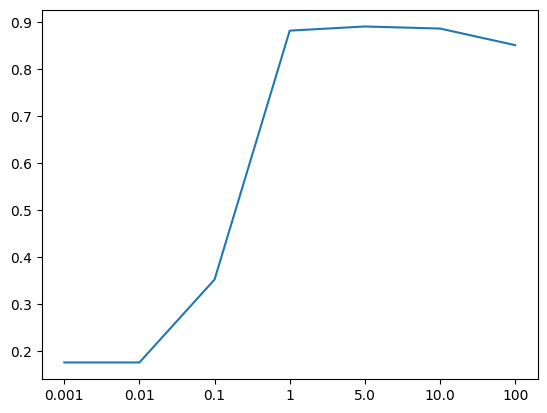

In [28]:
import seaborn as sns

fig = sns.lineplot(x=list(range(0, 7)), y=list_acc)
fig.set_xticks(range(0, 7))
fig.set_xticklabels([0.001, 0.01, 0.1, 1, 5.0, 10.0, 100])

In [29]:
# hàm sinh id màu
def get_cmap(n):
    return "C" + str(n)
# Hàm thực hiện training model, crossvalidate và vẽ lên đồ thị sử dụng matlibplot

In [33]:
def plot_learning_curve(estimator, title, label_curve, X, y, ylim=None, cv=None, n_jobs=1, train_sizes=np.linspace(0.1, 1.0, 5), new_plot=False, idx_color=0):
    # Khởi tạo bức ảnh mới với thư viện plot lib
    if new_plot:
    # plt.figure()
        plt.title(title)
        plt.xlabel("Training examples")
        plt.ylabel("Accuracy")
        plt.grid()
    # chú thích nếu có
    if ylim is not None:
        plt.ylim(*ylim)
    # thực hiện training model, ghi nhận các giá trị trong quá trình training
    # cv = số fold cross validate, số phần bộ dữ liệu được chia để thực hiện training testing.
    # train_sizes = mảng tỉ lệ, các tỉ lệ được hệ thống chọn làm điểm dừng để thực hiện 1 testing
    # train_sizes = [0.3, 0.5] => hệ thống lấy 30 % dữ liệu để train và thực hiện test, tương tự 50 % ..
    # scoring = hàm mục tiêu để đánh giá chất lượng mô hình và vẽ lên đồ thị
    train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring="accuracy")
    # Lấy trung bình cộng các giá trị output của các fold
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    # random 1 màu để vẽ
    color = get_cmap(idx_color)
    # thực hiện vẽ các giá trị số lên đồ thị với màu vừa được random
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std, test_scores_mean + test_scores_std, alpha=0.1, color=color)
    plt.plot(train_sizes, test_scores_mean, "o-", color=color, label=label_curve)
    plt.legend(loc="best")
    return plt

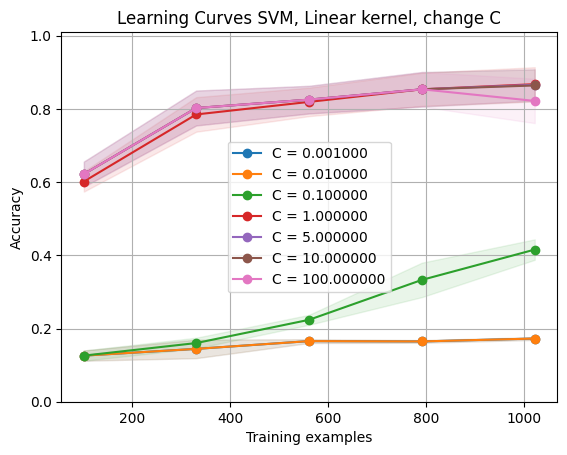

In [34]:
list_C = [0.001, 0.01, 0.1, 1, 5.0, 10.0, 100]
# model title
title = "Learning Curves SVM, Linear kernel, change C"
# duyệt qua mảng các giá trị của tham số C
for i, C in enumerate(list_C):
    # Với từng giá trị C nhận được,
    # thực hiện build model và training cross-validate
    # vẽ kết quả tìm được lên đồ thị đường.
    text_clf = Pipeline(
        [
            ("clf", svm.SVC(kernel="linear", C=C)), # mô hình svm với tham số C
        ]
    )
    plt = plot_learning_curve(text_clf, title, "C = %f" % (C), data_preprocessed, data_train.target, (0.0, 1.01), cv=10, n_jobs=-1, idx_color=i, new_plot=i == 0)
# lưu hình ảnh ra file
# plt.savefig('images/changeC.png', bbox_inches='tight')
plt.show()

In [35]:
params_grid = {"C": [0.001, 0.01, 0.1, 1, 10, 100], "gamma": [0.0001, 0.001, 0.01, 0.1], "kernel": ["linear", "rbf", "poly"]}
model = svm.SVC()
# Create the GridSearchCV object
best_model = GridSearchCV(model, params_grid, cv=4, n_jobs=-1, scoring="accuracy")
# Fit the data with the best possible parameters
best_model.fit(X_train, y_train)
# Print the best estimator with it's parameters
print(best_model.best_params_)
print(best_model.best_estimator_)
# Test best_model
print("Testing")
y_pred = best_model.predict(X_test)
print(accuracy_score(y_test, y_pred))


{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
SVC(C=100, gamma=0.01)
Testing
0.8898678414096917


Dữ liệu training =  (1437, 64) (1437,)
Dữ liệu testing =  (360, 64) (360,)


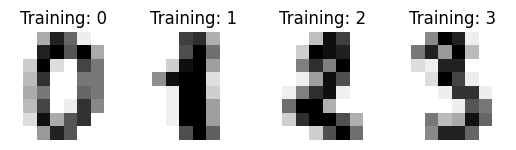

In [36]:
# Standard scientific Python imports
import matplotlib.pyplot as plt
# Import datasets, classifiers and performance metrics
from sklearn import datasets, svm, metrics
# The digits dataset
digits = datasets.load_digits()
# The data that we are interested in is made of 8x8 images of digits, let's
# have a look at the first 4 images, stored in the `images` attribute of the
# dataset. If we were working from image files, we could load them using
# matplotlib.pyplot.imread. Note that each image must have the same size. For these
# images, we know which digit they represent: it is given in the 'target' of
# the dataset.
images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:4]):
    plt.subplot(2, 4, index + 1)
    plt.axis("off")
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    plt.title("Training: %i" % label)
# To apply a classifier on this data, we need to flatten the image, to
# turn the data in a (samples, feature) matrix:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))
target = digits.target
X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=test_size)

print("Dữ liệu training = ", X_train.shape, y_train.shape)
print("Dữ liệu testing = ", X_test.shape, y_test.shape)

Accuracy: 0.9888888888888889


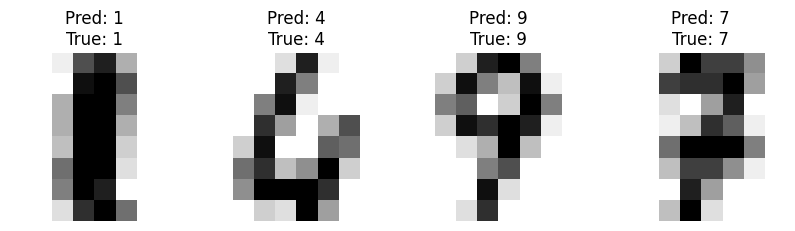

In [39]:
##### exercise #####
# Yêu cầu: Ứng dụng mô hình svm vào bài toán phân loại ảnh

# 1. Initialize and Train the model
# Using RBF kernel which is generally better for image data
model = svm.SVC(gamma=0.001, C=100, kernel='rbf')
model.fit(X_train, y_train)

# 2. Predict on the test set
y_pred = model.predict(X_test)

# 3. Evaluate accuracy
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

# 4. Visualize predictions alongside images
# We assume X_test contains flattened arrays (64 elements), so we reshape them to 8x8
images_and_predictions = list(zip(X_test, y_pred, y_test))

plt.figure(figsize=(10, 4))
for index, (image, prediction, actual) in enumerate(images_and_predictions[:4]):
    plt.subplot(1, 4, index + 1)
    plt.axis('off')
    # Reshape back to 8x8 to display
    plt.imshow(image.reshape(8, 8), cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'Pred: {prediction}\nTrue: {actual}')

plt.show()

######################